# 4 · Training & Reliability  `[TRAINING ↔ EVAL]`

The training-signal health AND whether that signal can be trusted. Per arm: the TensorBoard curves, per-candidate reward spread, method-native advantage, degeneration check — then the **reward-faithfulness** question: is the short partial-conversation training reward a faithful proxy for the full-conversation eval, and does look-ahead help? Exports → `results/<VIEW>/figures/4_training/`. For a reader debugging *why* an arm did or didn't learn, or questioning the reward design.

In [ ]:
import sys, os; sys.path.insert(0, os.path.abspath("."))
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
pd.set_option("display.width", 185, "display.max_columns", 50)
import eda_analysis
from eda_analysis import stats, behavior, training, pref, figures, plots

# ╔═══ VIEW — the one knob ════════════════════════════════════════════════════════╗
# "all" = every arm | "L0" = K=0 arms (PTO_LA0/GRPO_LA0) | "L5" = K=5 arms (thin, paused).
# Sets BOTH the arm filter AND the results root -> results/<VIEW>/figures|tables/<group>/.
# Edit the default for interactive use; render_views.py overrides it via the EDA_VIEW env var.
VIEW = os.environ.get("EDA_VIEW", "L0")

cfg = eda_analysis.EdaConfig(
    view=VIEW,                             # arm filter + results/<VIEW>/ root
    export_group="4_training",             # topic family = this notebook's number
    selection="all",
    focus_arms=None, focus_metric="Q1Q2",
)
S = eda_analysis.notebook_setup(cfg)
FOCUS = cfg.focus_arms or sorted(S.SCORES.arm.unique())

## 1 · Training curves (TensorBoard)  `[TRAINING]`
**Purpose.** The optimiser-side curves per arm, chained across iterations (dotted lines = iteration boundaries): GRPO loss / reward / reward_std / KL / entropy / completion length; DPO loss / rewards / margins / accuracies / logps. Parsed straight from the run's event files.

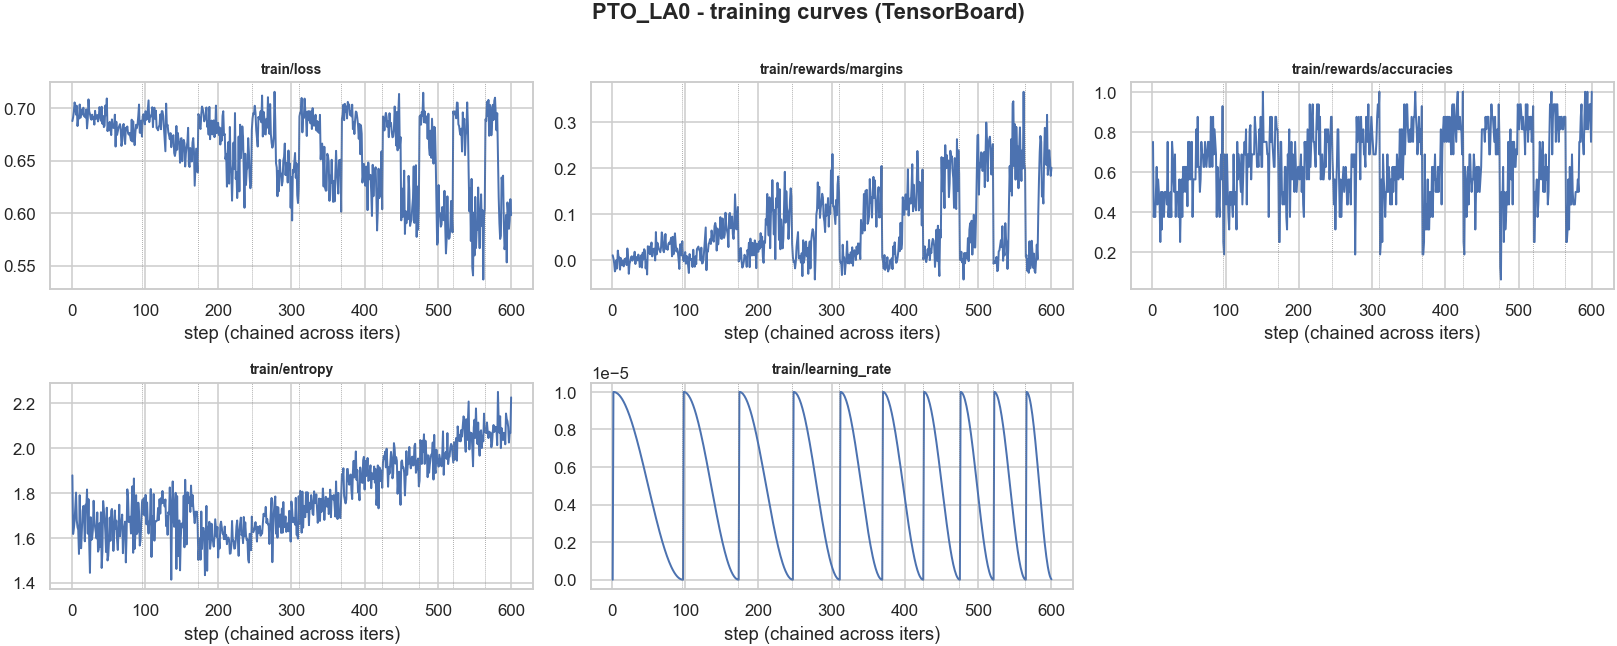

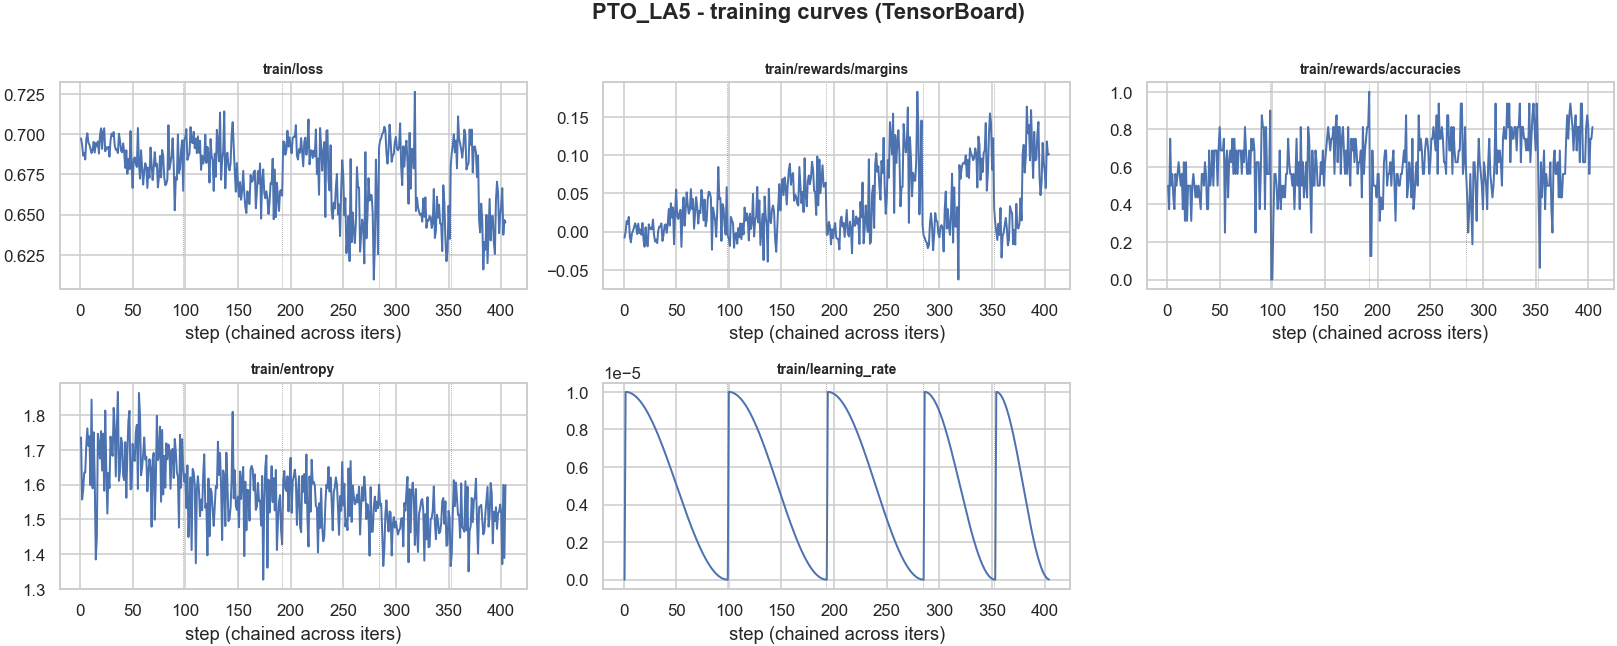

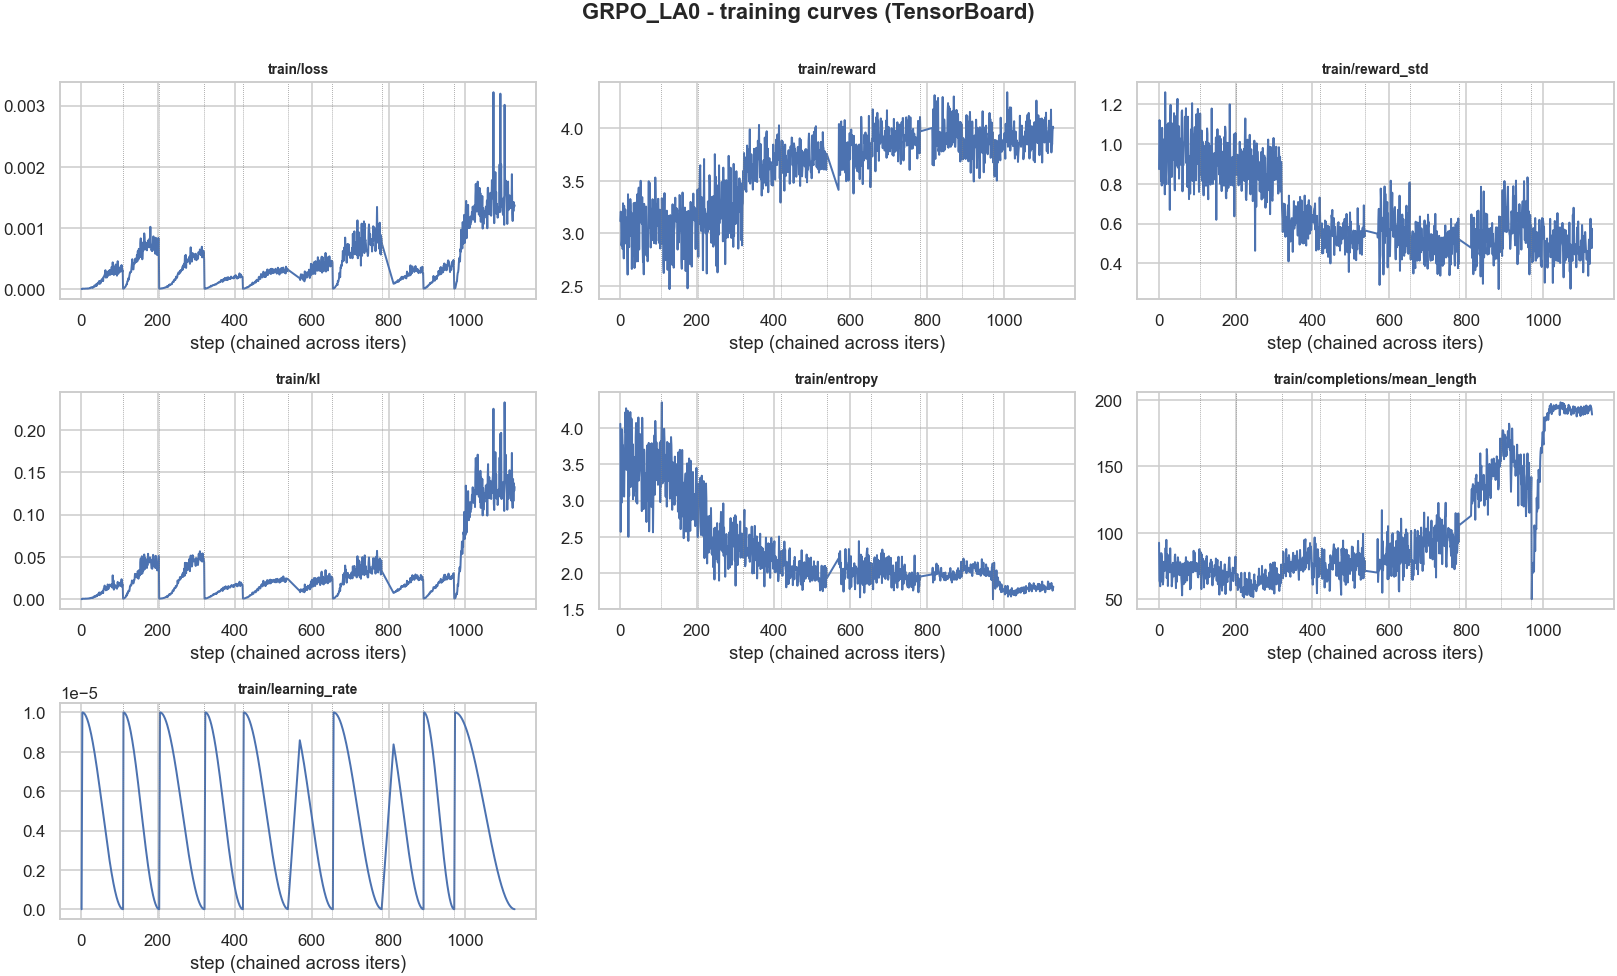

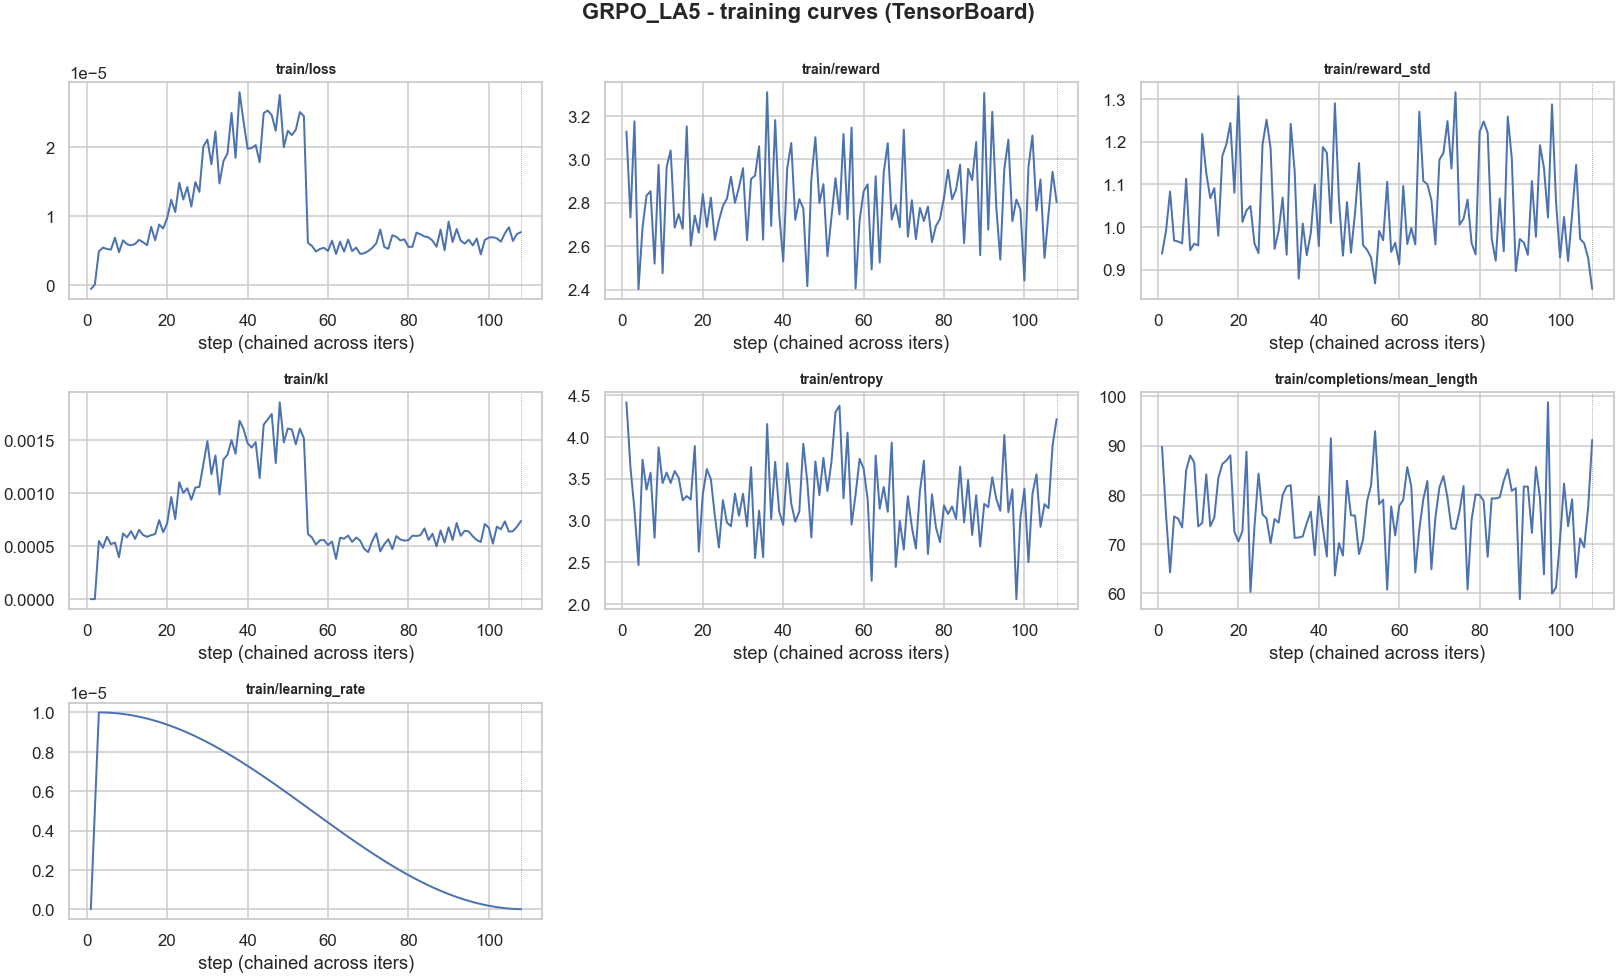

In [2]:
for arm in S.ARMS:
    fig = training.tb_curves(arm)
    if fig is not None:
        fig.suptitle(f"{arm.label} - training curves (TensorBoard)", y=1.0, fontweight="bold"); plt.show()

## 2 · Candidate reward + advantage signal  `[TRAINING]`
**Purpose.** What the oracle handed back per candidate (partial-branch reward), and how **decisively** the oracle separates a group's candidates — now on ONE comparable *oracle-score-gap* scale: GRPO **best−worst group range** (the direct analog to a preference margin; `group_std` shown faint) beside PTO **chosen−rejected margin** (median faint). **Read:** a shrinking gap = the training signal saturating; PTO's margin declines steadily while GRPO's range dips mid-training then **rebounds late** (echoing the iter-8 reward-hack). Combined `reward_distribution_by_arm.png` + a per-arm zoom in `4_training/reward_distribution/<arm>.png`.

In [ ]:
RWD = training.reward_distribution_frame(S.ARMS)
fig = plots.reward_distribution(RWD)
if fig: eda_analysis.save_fig(fig, "reward_distribution_by_arm", caption="Per-candidate training reward per iteration, one panel per arm (oracle on partial-conv branches, not the full-conv eval)."); plt.show()

# Per-arm zoom — the 4_training/reward_distribution/ subfolder companion to the combined grid above.
if not RWD.empty:
    for arm in sorted(RWD.arm.unique()):
        figa = plots.reward_distribution(RWD[RWD.arm == arm], ncols=1)
        if figa is None:
            continue
        eda_analysis.save_fig(figa, arm, group="4_training/reward_distribution",
                              caption=f"{arm}: per-candidate training-reward distribution per iteration (partial-conv oracle, not the full-conv eval).")
        plt.show()

ADV = training.advantage_signal_by_iter(S.ARMS)
fig = plots.advantage_signal_sidebyside(ADV)
if fig: eda_analysis.save_fig(fig, "advantage_signal_sidebyside", caption="Training decisiveness on ONE comparable scale (oracle-score gap): GRPO per-group best−worst reward range (within-group std faint) vs PTO chosen−rejected margin (median faint), per iteration. PTO's margin declines steadily; GRPO's range dips mid-training then rebounds late, echoing the iter-8 reward-hack regression."); plt.show()

## 3 · Degeneration check  `[TRAINING]`
**Purpose.** Confirm the ChatML-leak / empty / floored-completion fixes held in the real runs. **Read:** `pct_leak`/`pct_empty` near 0 = clean; a spike flags a generation pathology that turn.

In [4]:
DEG = training.scan_degeneracy(training.load_generations(S.ARMS))
display(DEG[["arm", "train_iter", "n_candidates", "pct_leak", "pct_empty", "pct_floored", "mean_score"]] if not DEG.empty else DEG)

,arm,train_iter,n_candidates,pct_leak,pct_empty,pct_floored,mean_score
0,GRPO_LA0,1,14352,0.0,0.18,0.18,3.074450
1,GRPO_LA0,2,6160,0.0,0.03,0.03,3.043861
2,GRPO_LA0,3,16032,0.0,0.01,0.01,3.252195
3,GRPO_LA0,4,13440,0.0,0.00,0.00,3.662654
4,GRPO_LA0,5,15600,0.0,0.00,0.00,3.729112
5,GRPO_LA0,6,11904,0.0,0.00,0.00,3.741878
6,GRPO_LA0,7,16976,0.0,0.00,0.00,3.920210
7,GRPO_LA0,8,10448,0.0,0.00,0.00,3.963808
8,GRPO_LA0,9,10656,0.0,0.00,0.00,3.863876
9,GRPO_LA0,10,21296,0.0,0.00,0.00,3.910926


## 4 · Reward faithfulness — rank agreement vs conversation length  `[TRAINING ↔ EVAL]`
**Purpose.** Rebuild the Exp2 partial-conv statistic on Exp3 data (from the per-branch `prefix` in `generations.jsonl`, no new oracle calls): for each scored length `n_turns`, the fraction of conversation pairs whose proxy-score ordering matches the full-conv eval ordering. **Read:** 0.5 = chance; higher = more faithful. Comparing **LA0 vs LA5** tests whether look-ahead buys faithfulness. MCL=12 keeps the shortest training cut out of the unreliable regime (Exp2 saw 0.66 at n_turns=2).

In [ ]:
BR = training.load_branch_reliability(S.ARMS)
RA = stats.rank_agreement_by_nturns(BR, S.SCORES, metric="Q1Q2")
fig = plots.reliability_curve(RA, palette=S.PALETTE)
if fig: eda_analysis.save_fig(fig, "reward_reliability_curve", caption="Sign-agreement between the partial-conv training reward and the full-conv eval (Q1+Q2) vs the length at which the conversation was scored; per arm. 0.5 = chance. LA0 vs LA5 tests whether look-ahead improves faithfulness."); plt.show()
if not RA.empty:
    display(RA.pivot_table(index="n_turns", columns="arm", values="agreement").round(3))

## 5 · Proxy reward vs full-conv eval, per iteration  `[TRAINING ↔ EVAL]`
**Purpose.** The aggregate view: mean training proxy reward vs mean full-conv eval per (arm, iteration), dashed y=x. **Read:** points below the line = the proxy over-rates the policy (promising openings that don't pay off by session end).

In [ ]:
GENS = training.load_generations(S.ARMS)
fig = plots.faithfulness_proxy_vs_eval(S.SCORES, GENS)
if fig: eda_analysis.save_fig(fig, "faithfulness_proxy_vs_eval", caption="Per (arm, iteration): mean training proxy reward (oracle on the partial branch) vs full-conversation eval Q1+Q2; dashed y=x."); plt.show()

## 6 · PTO preference decisiveness by branch depth  `[TRAINING]`
**Purpose.** Within PTO, how the chosen-rejected score `margin` varies with `branch_depth` (deeper = later in the trunk = longer prefix). **Read:** a margin that grows with depth = the oracle discriminates more confidently on longer context. (PTO-only — GRPO has no pairs. Inline only — not exported.)

In [ ]:
PP = training.load_pref_pairs([a for a in S.ARMS if a.method == "PTO"])
if not PP.empty and "branch_depth" in PP.columns:
    g = PP.groupby(["arm", "branch_depth"])["margin"].mean().reset_index()
    fig, ax = plt.subplots(figsize=(8, 4.2))
    sns.lineplot(g, x="branch_depth", y="margin", hue="arm", marker="o", palette=figures.arm_palette(sorted(g.arm.unique())), ax=ax)
    ax.axhline(0, color="grey", lw=0.6, ls="--"); ax.set_title("PTO chosen-rejected margin by branch depth")
    ax.set_xlabel("branch depth (deeper = longer prefix)"); ax.set_ylabel("mean score margin")
    figures.relabel_legend(ax); fig.tight_layout(); plt.show()
else:
    print("No PTO preference pairs available.")

## 7 · How to read this notebook
- **Curves (§1)** are the ground truth of optimisation; a flat/exploding loss or collapsing `reward_std` explains a stalled arm.
- **Advantage (§2)** shrinking toward 0 (GRPO `group_std`, PTO `margin`) = the training signal is running out — expect the eval curve (`1_Outcomes`) to plateau.
- **Degeneration (§3)** should stay ~0; this is the health gate, not a result.
- The **reliability curve (§4)** is the faithfulness headline: it quantifies how much the training reward can be trusted at the length it actually scores. MCL=12 was chosen to stay out of the unreliable short-cut regime. **LA0 vs LA5:** if LA5 sits above LA0, look-ahead is making the short reward more faithful — the original motivation for the K knob.
- _(The held-out outcomes live in `1_Outcomes`; behaviour/mechanism in `3_Mechanism`.)_

In [ ]:
print("index ->", eda_analysis.build_index())